===== AAPL 股票分析报告 =====
时间范围: 2025-04-22 至 2026-04-21
总交易日: 251
收盘价最高: $ 286.19
收盘价最低: $ 195.27
平均收盘价: $ 242.74
平均日收益率:  0.13 %
最大单日涨幅:  6.18 %
最大单日跌幅:  -5.0 %


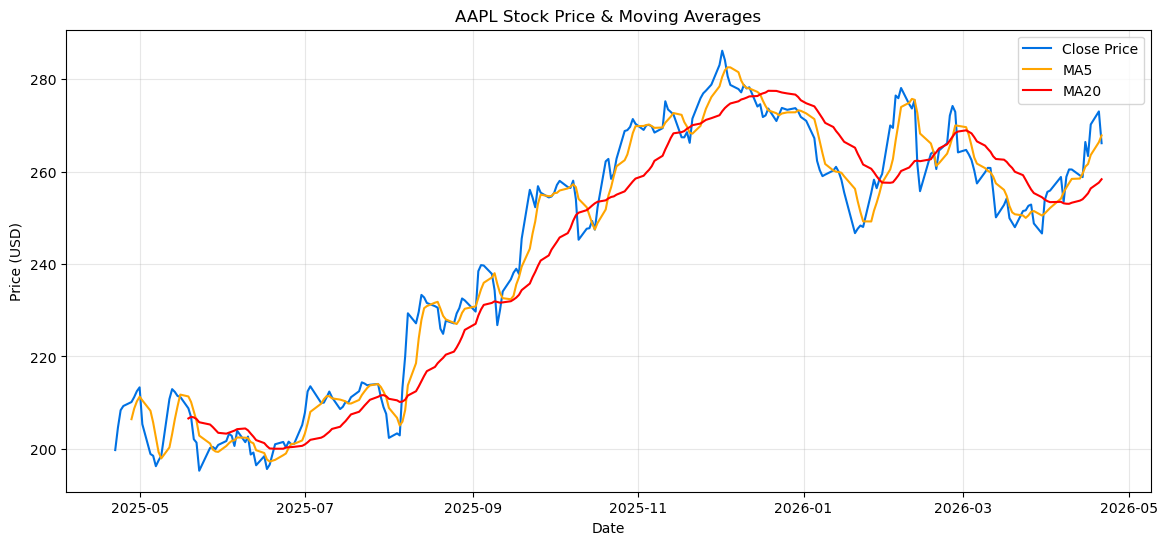

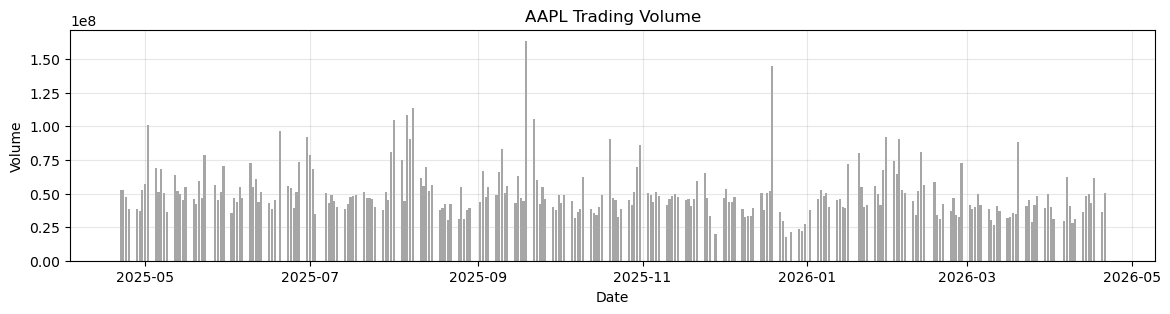

In [1]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("HistoricalData_1776827653573.csv")

df['Date'] = pd.to_datetime(df['Date'])
df['Close'] = df['Close/Last'].str.replace('$', '').astype(float)
df['Open'] = df['Open'].str.replace('$', '').astype(float)
df['High'] = df['High'].str.replace('$', '').astype(float)
df['Low'] = df['Low'].str.replace('$', '').astype(float)

df = df.sort_values('Date').reset_index(drop=True)
df['Daily_Return'] = df['Close'].pct_change() * 100
df['MA5'] = df['Close'].rolling(5).mean()
df['MA20'] = df['Close'].rolling(20).mean()
print("===== AAPL 股票分析报告 =====")
print("时间范围:", df.Date.min().date(), "至", df.Date.max().date())
print("总交易日:", len(df))
print("收盘价最高: $", round(df.Close.max(), 2))
print("收盘价最低: $", round(df.Close.min(), 2))
print("平均收盘价: $", round(df.Close.mean(), 2))
print("平均日收益率: ", round(df.Daily_Return.mean(), 2), "%")
print("最大单日涨幅: ", round(df.Daily_Return.max(), 2), "%")
print("最大单日跌幅: ", round(df.Daily_Return.min(), 2), "%")
plt.figure(figsize=(14, 6))
plt.plot(df.Date, df.Close, label='Close Price', color='#0071e3')
plt.plot(df.Date, df.MA5, label='MA5', color='orange')
plt.plot(df.Date, df.MA20, label='MA20', color='red')
plt.title('AAPL Stock Price & Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
plt.figure(figsize=(14, 3))
plt.bar(df.Date, df.Volume, color='gray', alpha=0.7)
plt.title('AAPL Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(alpha=0.3)
plt.show()